In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm import tqdm
import json, os, gc
from datasets import load_dataset
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils

# ====================== CONFIG ======================
MODEL_NAME = "Qwen/Qwen3-4B"
DEVICE = "cuda"
BATCH_SIZE = 8          # Very conservative for 8B
EPOCHS = 16
LR = 5e-4

ACTIVATION_TYPES = [
    # "resid_post",
                     "mlp_post", 
                     "attn_out"
                     ]  # Add more as needed
LAYER_PERCENTAGES = [
    0.4,
      0.5, 0.6, 0.8, 0.9, 
                    #  1.0
                     ]

SAVE_DIR = "./harmfulness_activations_qwen3_MixTox"
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
N_SAMPLES = 8000

In [3]:
from datasets import load_dataset


print("Loading real-toxicity-prompts")

    # Note: You may need to accept terms on HuggingFace first
ds = load_dataset("allenai/real-toxicity-prompts", split="train")
    
harmful_texts = []
benign_texts = []
    



Loading real-toxicity-prompts


Extracting characteristics...
Collected 8001 samples


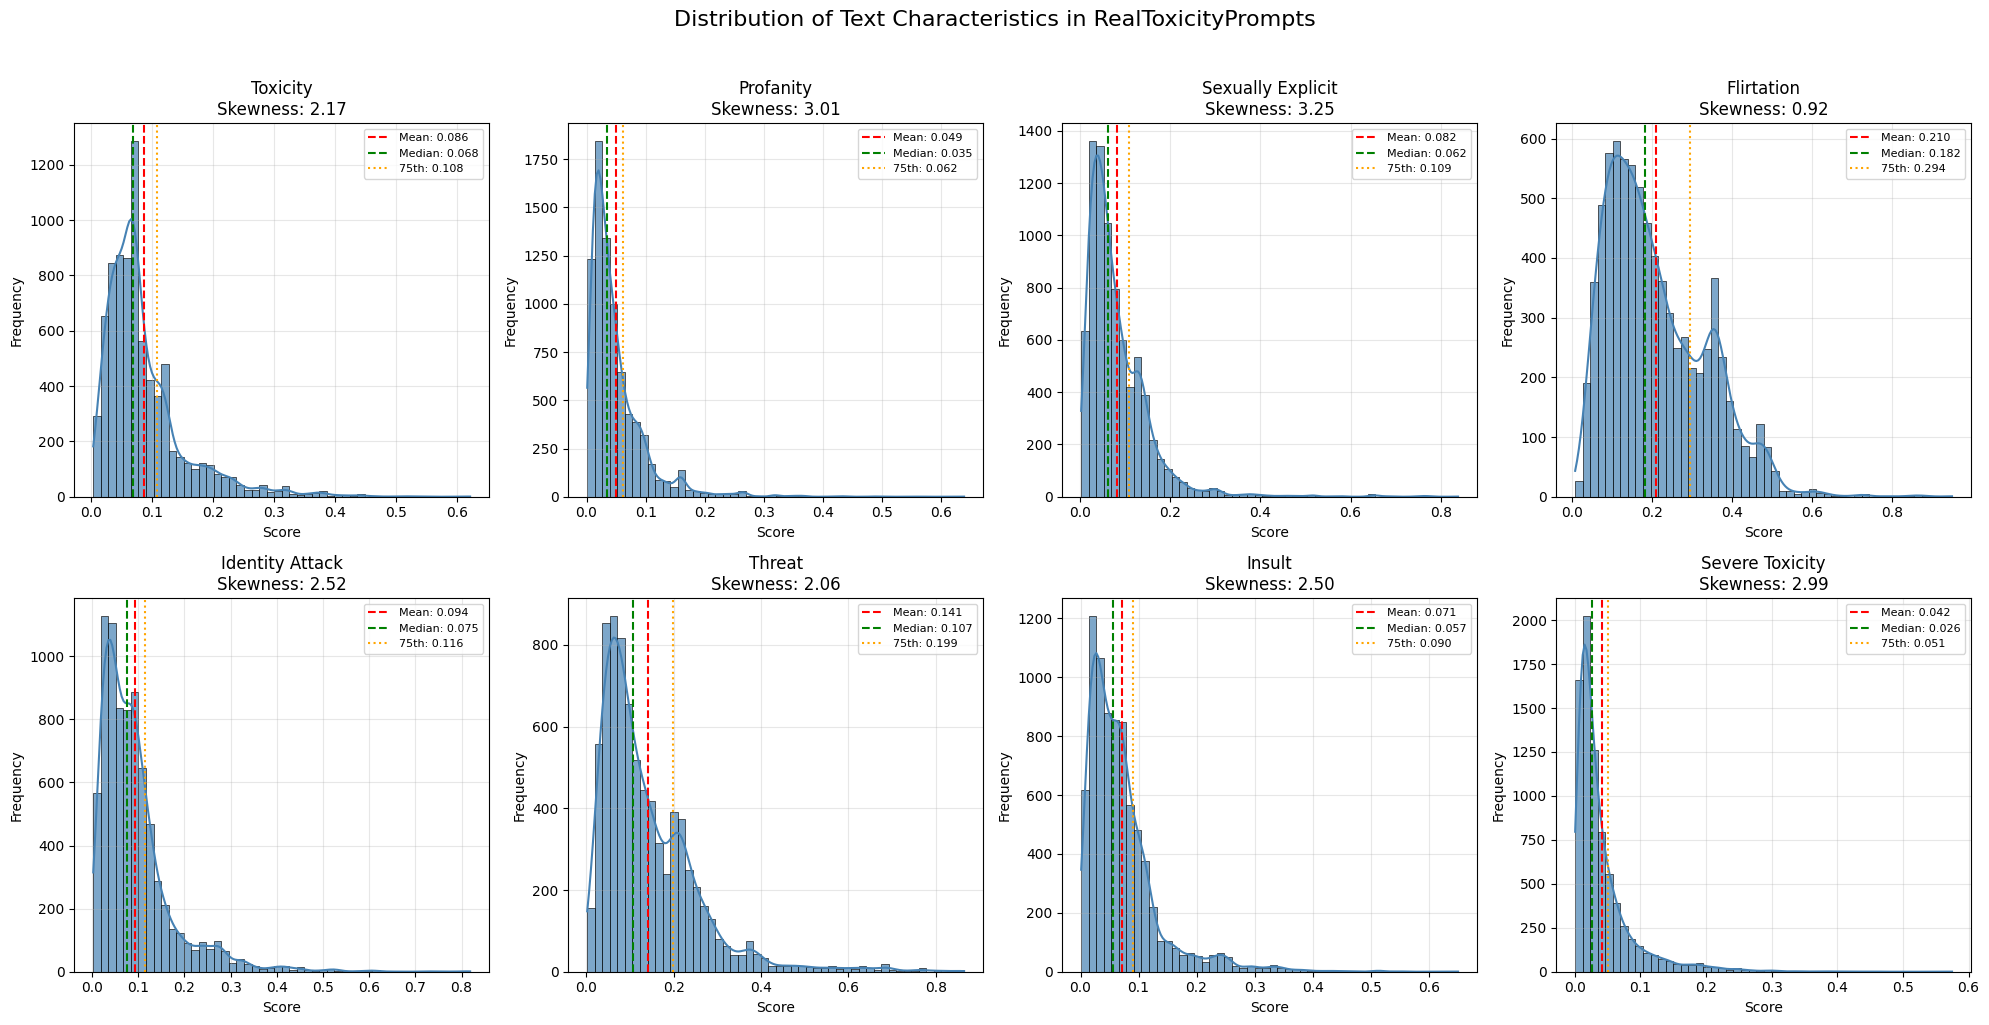


STATISTICAL SUMMARY
   Characteristic   Mean Median    Std Skewness Kurtosis 95th Percentile 99th Percentile
         toxicity 0.0863 0.0685 0.0674    2.174    6.655          0.2243          0.3503
        profanity 0.0491 0.0346 0.0480    3.013   15.429          0.1416          0.2503
sexually_explicit 0.0816 0.0621 0.0707    3.250   19.531          0.1952          0.3429
       flirtation 0.2105 0.1819 0.1236    0.918    0.935          0.4398          0.5156
  identity_attack 0.0938 0.0753 0.0818    2.518   10.028          0.2620          0.4137
           threat 0.1408 0.1075 0.1128    2.064    6.408          0.3496          0.6064
           insult 0.0710 0.0566 0.0634    2.500    9.439          0.2004          0.3275
  severe_toxicity 0.0417 0.0257 0.0473    2.989   12.925          0.1372          0.2347

THRESHOLD ESTIMATION

Recommended thresholds (by method):

   Characteristic Mean+1σ 75th %ile 90th %ile 95th %ile IQR (Q3+1.5*IQR)
         toxicity  0.1537    0.1077    0.1741

/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

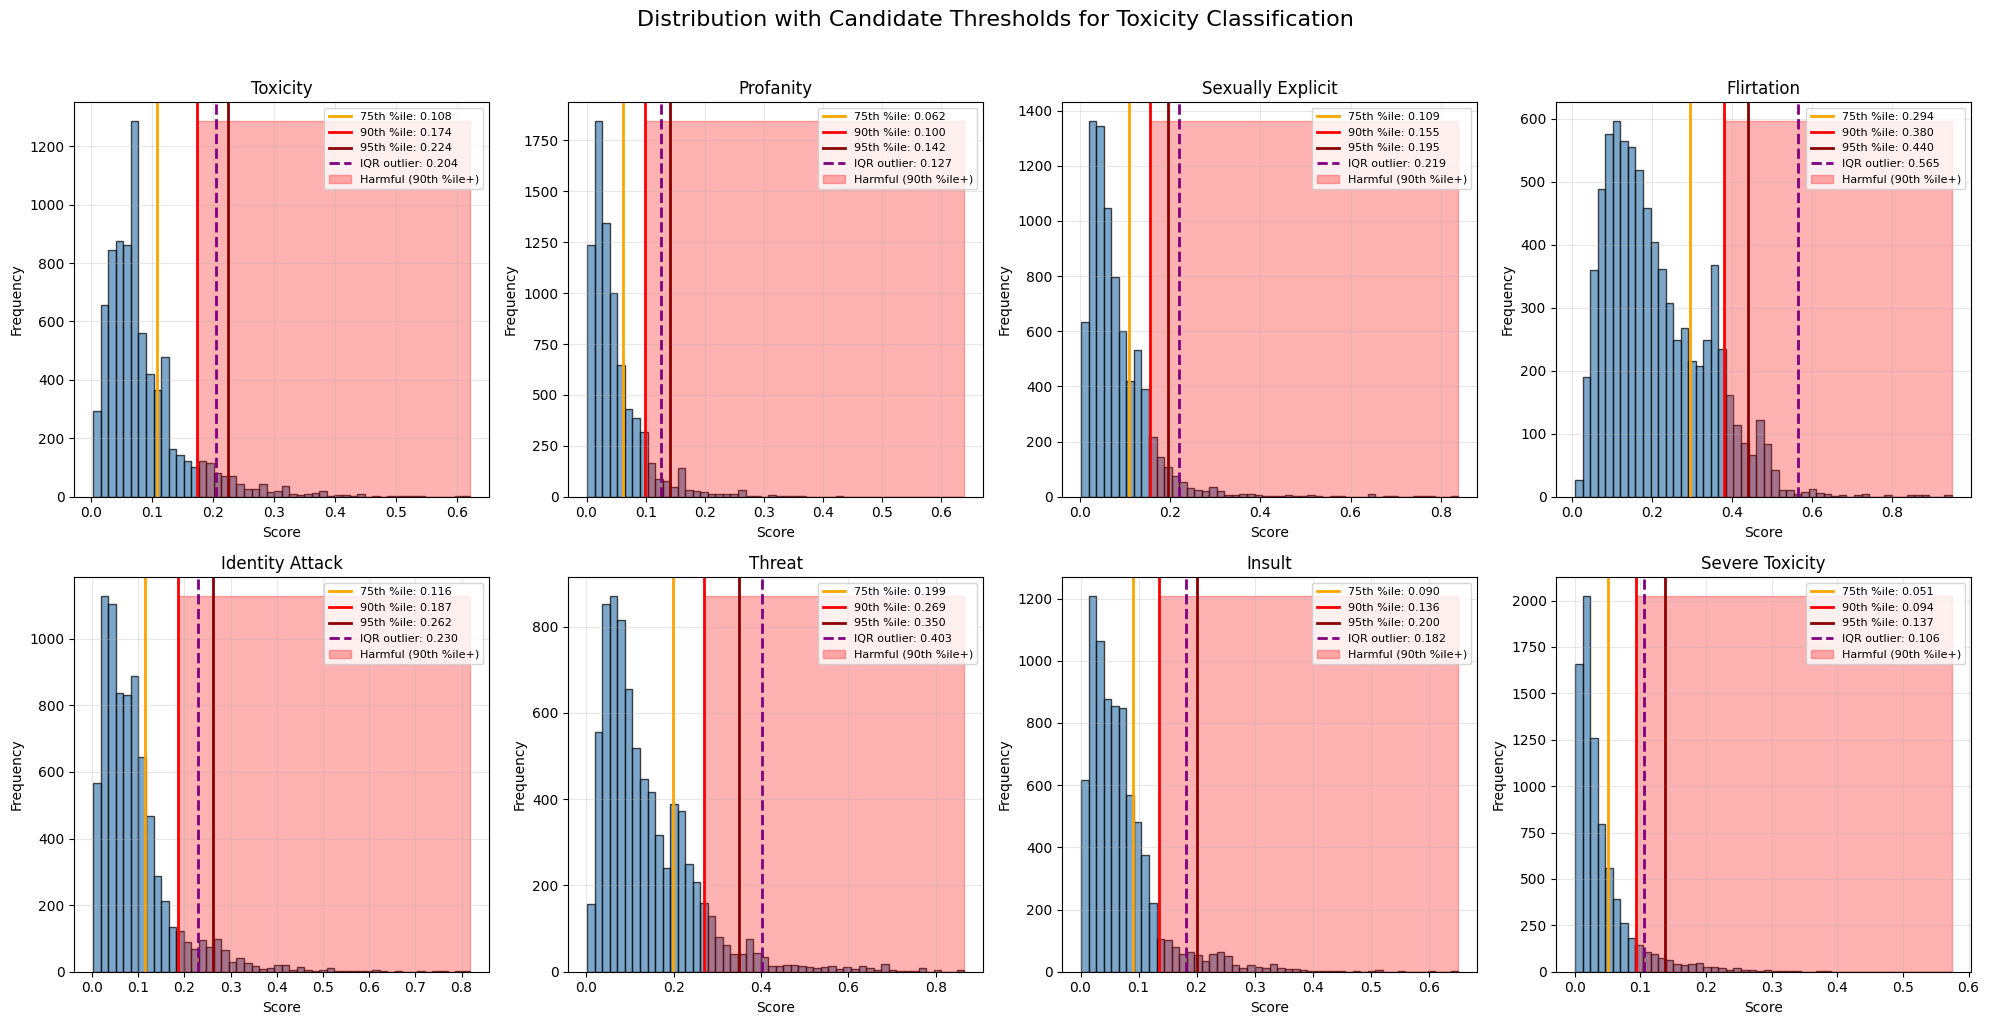

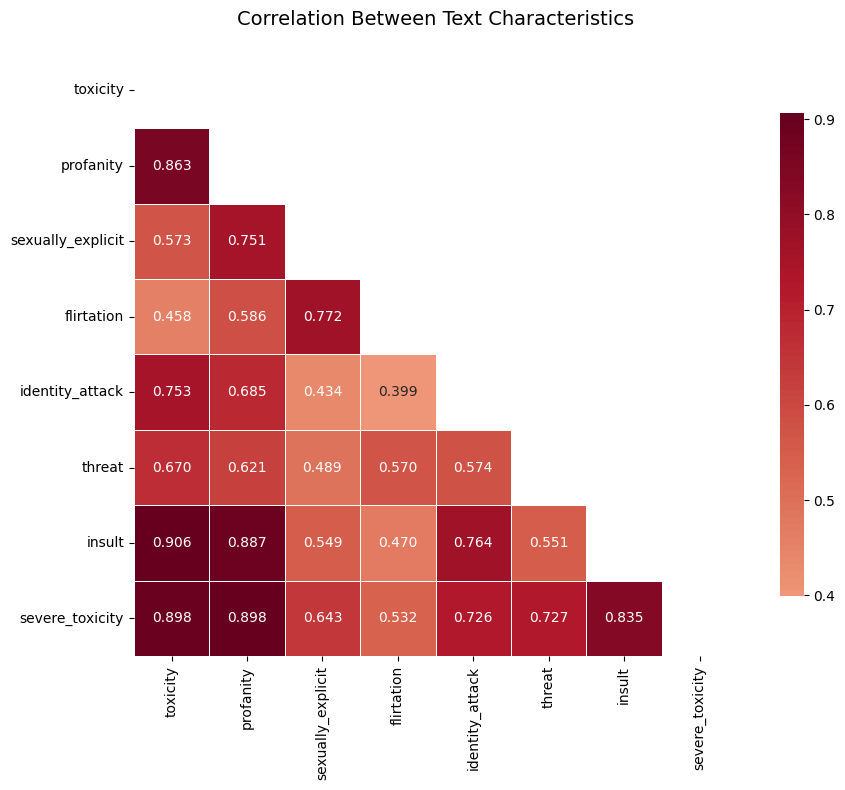

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from scipy import stats



# Extract all text characteristics
characteristics = ['toxicity', 'profanity', 'sexually_explicit', 'flirtation', 
                   'identity_attack', 'threat', 'insult', 'severe_toxicity']

# Collect data from prompts (since your example shows prompt has the main scores)
data = {char: [] for char in characteristics}

print("Extracting characteristics...")
for i, ex in enumerate(ds):
    if i > N_SAMPLES:
        break
    prompt_scores = ex['prompt']
    for char in characteristics:
        if char in prompt_scores:
            data[char].append(prompt_scores[char])
    
    # Limit for memory - use 100k samples for distribution analysis
    if i >= 100000:
        break

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Collected {len(df)} samples")

# ============================================================
# 1. DISTRIBUTION PLOTS FOR ALL CHARACTERISTICS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, char in enumerate(characteristics):
    ax = axes[idx]
    
    # Histogram with KDE
    sns.histplot(df[char], bins=50, kde=True, ax=ax, color='steelblue', alpha=0.7)
    
    # Statistics
    mean_val = df[char].mean()
    median_val = df[char].median()
    percentile_75 = df[char].quantile(0.75)
    percentile_90 = df[char].quantile(0.90)
    
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.3f}')
    ax.axvline(percentile_75, color='orange', linestyle=':', label=f'75th: {percentile_75:.3f}')
    
    ax.set_title(f'{char.replace("_", " ").title()}\nSkewness: {df[char].skew():.2f}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Text Characteristics in RealToxicityPrompts', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('characteristics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 2. STATISTICAL SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

summary_stats = []
for char in characteristics:
    summary_stats.append({
        'Characteristic': char,
        'Mean': f"{df[char].mean():.4f}",
        'Median': f"{df[char].median():.4f}",
        'Std': f"{df[char].std():.4f}",
        'Skewness': f"{df[char].skew():.3f}",
        'Kurtosis': f"{df[char].kurtosis():.3f}",
        '95th Percentile': f"{df[char].quantile(0.95):.4f}",
        '99th Percentile': f"{df[char].quantile(0.99):.4f}"
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

# ============================================================
# 3. THRESHOLD ESTIMATION USING MULTIPLE METHODS
# ============================================================
print("\n" + "="*80)
print("THRESHOLD ESTIMATION")
print("="*80)

thresholds = {}

# Method 1: Mean + 1 Standard Deviation
for char in characteristics:
    thresholds[f'{char}_mean+1std'] = df[char].mean() + df[char].std()

# Method 2: 75th Percentile (Q3)
for char in characteristics:
    thresholds[f'{char}_75th_percentile'] = df[char].quantile(0.75)

# Method 3: 90th Percentile (typical for outlier detection)
for char in characteristics:
    thresholds[f'{char}_90th_percentile'] = df[char].quantile(0.90)

# Method 4: 2 Standard Deviations from Mean (Gaussian assumption)
for char in characteristics:
    thresholds[f'{char}_2std'] = df[char].mean() + 2 * df[char].std()

# Method 5: Interquartile Range (IQR) method (Q3 + 1.5*IQR)
for char in characteristics:
    Q1 = df[char].quantile(0.25)
    Q3 = df[char].quantile(0.75)
    IQR = Q3 - Q1
    thresholds[f'{char}_iqr_outlier'] = Q3 + 1.5 * IQR

# Create threshold table
threshold_df = pd.DataFrame([
    {'Characteristic': char.split('_')[0], 
     'Method': method, 
     'Threshold': value}
    for method, value in thresholds.items()
    for char in [method]  # Hack for iteration
])

# Better: Direct table
print("\nRecommended thresholds (by method):\n")
threshold_table = []
for char in characteristics:
    threshold_table.append({
        'Characteristic': char,
        'Mean+1σ': f"{df[char].mean() + df[char].std():.4f}",
        '75th %ile': f"{df[char].quantile(0.75):.4f}",
        '90th %ile': f"{df[char].quantile(0.90):.4f}",
        '95th %ile': f"{df[char].quantile(0.95):.4f}",
        'IQR (Q3+1.5*IQR)': f"{df[char].quantile(0.75) + 1.5*(df[char].quantile(0.75)-df[char].quantile(0.25)):.4f}"
    })

threshold_table_df = pd.DataFrame(threshold_table)
print(threshold_table_df.to_string(index=False))

# ============================================================
# 4. OPTIMAL THRESHOLD FOR BINARY CLASSIFICATION
# ============================================================
print("\n" + "="*80)
print("OPTIMAL BINARY CLASSIFICATION THRESHOLDS")
print("="*80)

# For demonstration, we'll use 'toxicity' as the primary metric
# Load a sample with labels (if you have them, otherwise simulate)
# Assuming 'toxicity' > threshold = harmful

# Method: Use percentiles to define "high" toxicity
percentiles_to_test = [70, 75, 80, 85, 90, 95]

optimal_thresholds = {}
for char in characteristics:
    scores = df[char].values
    
    # For each candidate threshold (based on percentiles)
    best_f1 = 0
    best_threshold = 0.5
    
    # Simulate binary labels based on upper tail
    # This is self-consistent: top 20% = harmful
    for percentile in percentiles_to_test:
        threshold = np.percentile(scores, percentile)
        pred_labels = (scores > threshold).astype(int)
        true_labels = (scores > np.percentile(scores, 85)).astype(int)  # Assume top 15% are truly harmful
        
        f1 = f1_score(true_labels, pred_labels)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds[char] = {
        'threshold': best_threshold,
        'percentile': 100 * np.mean(scores <= best_threshold),
        'f1_score': best_f1
    }

optimal_df = pd.DataFrame([
    {'Characteristic': k, 
     'Optimal Threshold': v['threshold'],
     'Percentile': f"{v['percentile']:.1f}%",
     'F1 Score': f"{v['f1_score']:.3f}"}
    for k, v in optimal_thresholds.items()
])
print(optimal_df.to_string(index=False))

# ============================================================
# 5. VISUALIZE THRESHOLDS ON DISTRIBUTIONS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, char in enumerate(characteristics):
    ax = axes[idx]
    
    # Distribution
    n, bins, patches = ax.hist(df[char], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add threshold lines
    threshold_75 = df[char].quantile(0.75)
    threshold_90 = df[char].quantile(0.90)
    threshold_95 = df[char].quantile(0.95)
    threshold_iqr = df[char].quantile(0.75) + 1.5 * (df[char].quantile(0.75) - df[char].quantile(0.25))
    
    ax.axvline(threshold_75, color='orange', linestyle='-', linewidth=2, label=f'75th %ile: {threshold_75:.3f}')
    ax.axvline(threshold_90, color='red', linestyle='-', linewidth=2, label=f'90th %ile: {threshold_90:.3f}')
    ax.axvline(threshold_95, color='darkred', linestyle='-', linewidth=2, label=f'95th %ile: {threshold_95:.3f}')
    ax.axvline(threshold_iqr, color='purple', linestyle='--', linewidth=2, label=f'IQR outlier: {threshold_iqr:.3f}')
    
    # Highlight the "harmful" region (above threshold)
    y_max = max(n)
    x_fill = bins[bins >= threshold_90]
    if len(x_fill) > 0:
        ax.fill_betweenx([0, y_max], threshold_90, bins[-1], alpha=0.3, color='red', label='Harmful (90th %ile+)')
    
    ax.set_title(f'{char.replace("_", " ").title()}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution with Candidate Thresholds for Toxicity Classification', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('thresholds_on_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df[characteristics].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax, 
            cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Between Text Characteristics', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('characteristics_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
texts = []
labels = []

for ex in ds:
    text = ex['prompt']['text'] 
    scores = {**ex['prompt']}
    scores.pop('text')
    texts.append(text)
    labels.append(scores)

In [6]:
# ------------------ 2. LOAD MODEL ------------------
print("Loading Qwen3-4B...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    # fold_ln=True,
    # center_writing_weights=True,
    # center_unembed=True,
    dtype=torch.bfloat16,
    trust_remote_code=True,   # important for Qwen
)

print(f"Loaded model with {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")

Loading Qwen3-4B...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Loaded model with 36 layers, d_model=2560


In [7]:
# ------------------ 3. LINEAR PROBE ------------------
class LinearProbe(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [8]:
# ====================== SAVE ACTIVATIONS PER BATCH ======================
def save_activations(texts, labels, split_name="all"):
    """Save activations batch-by-batch to avoid OOM"""
    # tokenizer = model.tokenizer
    for act_type in ACTIVATION_TYPES:
        for rel_p in LAYER_PERCENTAGES:
            layer_idx = int(rel_p * model.cfg.n_layers)
            act_dir = f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split_name}"
            os.makedirs(act_dir, exist_ok=True)
            
            for i in tqdm(range(0, N_SAMPLES, BATCH_SIZE), desc=f"{act_type} L{layer_idx} {split_name}"):
                batch_texts = texts[i:i+BATCH_SIZE]
                batch_labels = labels[i:i+BATCH_SIZE]
                
                # tokens = tokenizer(batch_texts, padding=True, truncation=True,
                #                  max_length=1024, return_tensors="pt").input_ids.to(DEVICE)
                
                tokens = model.to_tokens(batch_texts)
                with torch.no_grad():
                    _, cache = model.run_with_cache(
                        tokens,
                        names_filter=lambda n: n == utils.get_act_name(act_type, layer_idx),
                        return_type=None
                    )
                    
                    act = cache[utils.get_act_name(act_type, layer_idx)]  # (batch, seq, d)
                    pooled = act.mean(dim=1).cpu()  # or act[:, -1, :] for last token
                    
                    # Save batch
                    torch.save({
                        "activations": pooled,
                        "labels": batch_labels
                    }, f"{act_dir}/batch_{i//BATCH_SIZE:06d}.pt")
                    
                    del cache, act, pooled
                    gc.collect()
                    torch.cuda.empty_cache()

In [9]:
save_activations(texts, labels)

attn_out L32 all: 100%|██████████| 1000/1000 [03:28<00:00,  4.79it/s]


In [3]:
def gather_full_tensor( act_type, layer_idx, split='all', trait='toxicity', quantile=.75):
    files = sorted([
            f for f in os.listdir(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}")
            if f.endswith(".pt")
     ])
    activations = []
    scores = []
    for file in files:
        f = torch.load(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}/{file}")
        
        a = [score_[trait] for score_ in f['labels']]
        if not all(ai is not None for ai in a):
            continue
        activations.append(f['activations'])
        scores.extend(a)
        
    activations = torch.cat(
        activations, dim=0
    )
    scores = torch.tensor(scores, dtype=torch.float32)
    thr = torch.quantile(scores, torch.scalar_tensor(quantile).to(scores.dtype))
    labels = (scores > thr).to(torch.float32)
    return activations, labels

In [2]:
# ====================== LOAD DATASET FROM DISK ======================
class ActivationDataset(torch.utils.data.Dataset):
    def __init__(self, act_type, layer_idx, split="train", trait='toxicity'):
        self.data, self.labels = gather_full_tensor(act_type, layer_idx, split, trait)

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        data = self.data[idx]
        return data, self.labels[idx]

In [4]:
TRAIT = 'toxicity'

In [5]:
# ====================== TRAINING ======================
import pandas as pd 


results = []
for act_type in ACTIVATION_TYPES:
    for rel_p in LAYER_PERCENTAGES:
        layer_idx = int(rel_p * 36)
        print(f"\n=== Training probe: {act_type} @ layer {layer_idx} ({rel_p*100:.0f}%) ===")
        
        generator = torch.Generator().manual_seed(42)
        full_dataset =  ActivationDataset(act_type, layer_idx, 'all')
        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset, lengths=[0.8, 0.2],
            generator=generator
        )
        
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)
        
        probe = nn.Sequential(
            nn.Linear(full_dataset.data[0].size(-1), 1),
            nn.Sigmoid()
        ).to(torch.float32).to(DEVICE)
        
        optimizer = optim.AdamW(probe.parameters(), lr=LR, weight_decay=1e-1)
        criterion = nn.BCELoss()
        
        # Training loop (same as before - abbreviated)
        best_auc = 0
        best_val_auc = 0
        best_state = None
        
        for epoch in range(EPOCHS):
            probe.train()
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(DEVICE).to(torch.float32), yb.squeeze().to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(probe(Xb).squeeze(), yb)
                loss.backward()
                optimizer.step()
            final_train_loss = loss.item()
            # Validation
            probe.eval()
            val_preds, val_true = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb = Xb.to(torch.float32).to(DEVICE)
                    preds = probe(Xb).cpu().squeeze().numpy()
                    val_preds.extend(preds)
                    val_true.extend(yb.numpy().squeeze())
            
            val_preds = np.array(val_preds)
            val_true = np.array(val_true)
            val_acc = accuracy_score(val_true, val_preds > 0.5)
            val_auc = roc_auc_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds > 0.5)
            
            print(f"Epoch {epoch+1:2d} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")
            
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
    
            # Save
            probe.load_state_dict(best_state)
            torch.save(best_state, f"{SAVE_DIR}/probe_l{layer_idx}_{act_type}.pt")
            
            results.append({"acc": val_acc, "auc": best_val_auc, "f1": val_f1, 'layer_idx': layer_idx, 'act_type': act_type, 'final_tr_loss': final_train_loss})
        
results = pd.DataFrame(results)

results.to_csv(f'lin_probes_{TRAIT}.csv')
print("Done. Results saved.")


=== Training probe: mlp_post @ layer 14 (40%) ===
Epoch  1 | Acc: 0.7433 | AUC: 0.7054 | F1: 0.0521
Epoch  2 | Acc: 0.7522 | AUC: 0.7383 | F1: 0.1572
Epoch  3 | Acc: 0.7542 | AUC: 0.7393 | F1: 0.1692
Epoch  4 | Acc: 0.7619 | AUC: 0.7501 | F1: 0.2382
Epoch  5 | Acc: 0.7644 | AUC: 0.7513 | F1: 0.2929
Epoch  6 | Acc: 0.7766 | AUC: 0.7580 | F1: 0.4021
Epoch  7 | Acc: 0.7670 | AUC: 0.7607 | F1: 0.3112
Epoch  8 | Acc: 0.7721 | AUC: 0.7638 | F1: 0.3438
Epoch  9 | Acc: 0.7747 | AUC: 0.7652 | F1: 0.3874
Epoch 10 | Acc: 0.7689 | AUC: 0.7668 | F1: 0.3182
Epoch 11 | Acc: 0.7683 | AUC: 0.7668 | F1: 0.3044
Epoch 12 | Acc: 0.7747 | AUC: 0.7688 | F1: 0.3874
Epoch 13 | Acc: 0.7728 | AUC: 0.7690 | F1: 0.4040
Epoch 14 | Acc: 0.7741 | AUC: 0.7699 | F1: 0.3669
Epoch 15 | Acc: 0.7721 | AUC: 0.7701 | F1: 0.3739
Epoch 16 | Acc: 0.7760 | AUC: 0.7704 | F1: 0.3993

=== Training probe: mlp_post @ layer 18 (50%) ===
Epoch  1 | Acc: 0.7407 | AUC: 0.7183 | F1: 0.0288
Epoch  2 | Acc: 0.7580 | AUC: 0.7245 | F1: 0.225

In [ ]:
EPOCHS = 200

In [11]:
results

[]

In [18]:
# ====================== TRAINING ======================
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import torch
from torch.utils.data import DataLoader

results = []

for act_type in ACTIVATION_TYPES:
    for rel_p in LAYER_PERCENTAGES:
        layer_idx = int(rel_p * 36)
        print(f"\n=== Training probe: {act_type} @ layer {layer_idx} ({rel_p*100:.0f}%) ===")
        
        generator = torch.Generator().manual_seed(42)
        full_dataset = ActivationDataset(act_type, layer_idx, 'all')
        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset, lengths=[0.8, 0.2],
            generator=generator
        )
        
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)
        
        # Convert torch dataloaders to numpy arrays for sklearn
        X_train, y_train = [], []
        for Xb, yb in train_loader:
            X_train.append(Xb.to(torch.float32).numpy())
            y_train.append(yb.to(torch.float32).numpy().squeeze())
        X_train = np.concatenate(X_train, axis=0)
        y_train = np.concatenate(y_train, axis=0)
        
        X_val, y_val = [], []
        for Xb, yb in val_loader:
            X_val.append(Xb.to(torch.float32).numpy())
            y_val.append(yb.to(torch.float32).numpy().squeeze())
        X_val = np.concatenate(X_val, axis=0)
        y_val = np.concatenate(y_val, axis=0)
        
        # Create sklearn pipeline with StandardScaler, PCA, and LogisticRegression
        probe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95)),  # Keep 95% variance
            ('classifier', LogisticRegression(
                C=10.0,
                max_iter=1000,
                random_state=42,
                penalty='l2',

            ))
        ])
        
        # Training
        probe.fit(X_train, y_train)
        
        # Validation predictions
        y_val_pred_proba = probe.predict_proba(X_val)[:, 1]
        y_val_pred = probe.predict(X_val)
        
        # Calculate metrics
        val_acc = accuracy_score(y_val, y_val_pred)
        val_auc = roc_auc_score(y_val, y_val_pred_proba)
        val_f1 = f1_score(y_val, y_val_pred)
        from sklearn.metrics import precision_score, recall_score
        val_precision = precision_score(y_val, y_val_pred)
        val_recall = recall_score(y_val, y_val_pred)
        
        print(f"Validation | Acc: {val_acc:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")
        
        # Save the pipeline
        import joblib
        joblib.dump(probe, f"{SAVE_DIR}/probe_l{layer_idx}_{act_type}.pkl")
        
        results.append({
            "acc": val_acc, 
            "auc": val_auc, 
            "f1": val_f1, 
            'recall': val_recall,
            'precision': val_precision,
            'layer_idx': layer_idx, 
            'act_type': act_type, 
            'final_tr_loss': None  # No loss tracking in sklearn version
        })

results = pd.DataFrame(results)
results.to_csv(f'lin_probes_{TRAIT}.csv')
print("Done. Results saved.")


=== Training probe: mlp_post @ layer 14 (40%) ===
Validation | Acc: 0.7202 | AUC: 0.6787 | F1: 0.4187

=== Training probe: mlp_post @ layer 18 (50%) ===
Validation | Acc: 0.7221 | AUC: 0.6900 | F1: 0.4355

=== Training probe: mlp_post @ layer 21 (60%) ===
Validation | Acc: 0.7330 | AUC: 0.7039 | F1: 0.4653

=== Training probe: mlp_post @ layer 28 (80%) ===
Validation | Acc: 0.7112 | AUC: 0.6747 | F1: 0.4332

=== Training probe: mlp_post @ layer 32 (90%) ===
Validation | Acc: 0.7131 | AUC: 0.6677 | F1: 0.4262

=== Training probe: attn_out @ layer 14 (40%) ===
Validation | Acc: 0.7555 | AUC: 0.7168 | F1: 0.4253

=== Training probe: attn_out @ layer 18 (50%) ===
Validation | Acc: 0.7484 | AUC: 0.7080 | F1: 0.4043

=== Training probe: attn_out @ layer 21 (60%) ===
Validation | Acc: 0.7407 | AUC: 0.7198 | F1: 0.3970

=== Training probe: attn_out @ layer 28 (80%) ===
Validation | Acc: 0.7638 | AUC: 0.7263 | F1: 0.4604

=== Training probe: attn_out @ layer 32 (90%) ===
Validation | Acc: 0.73

In [13]:
results = pd.read_csv(f'lin_probes_{TRAIT}.csv')

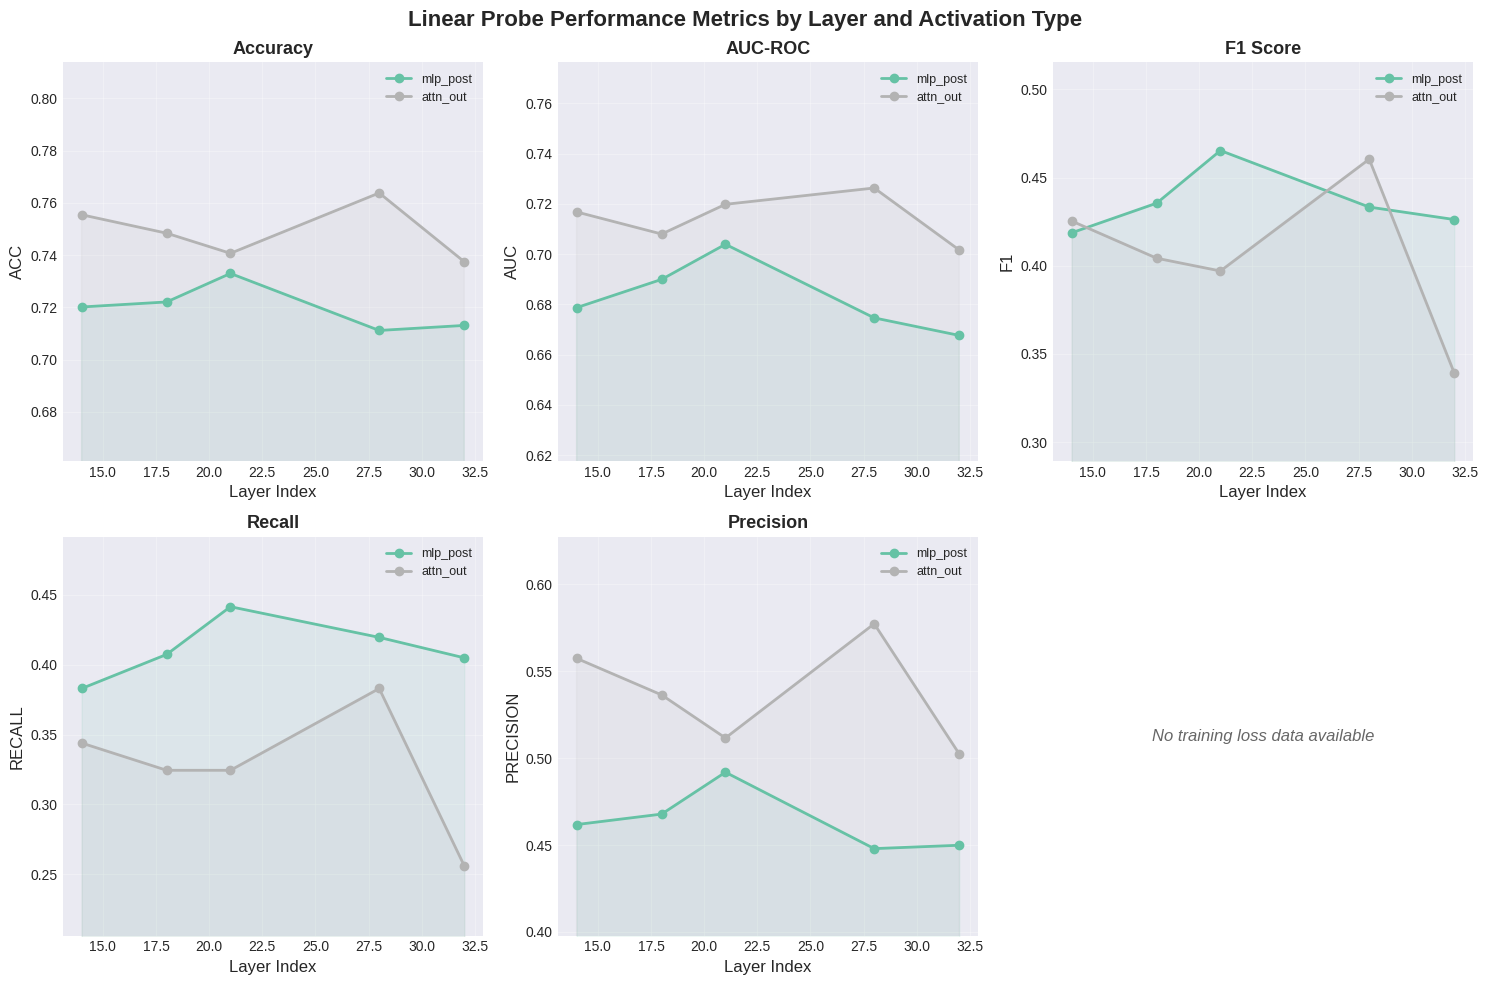

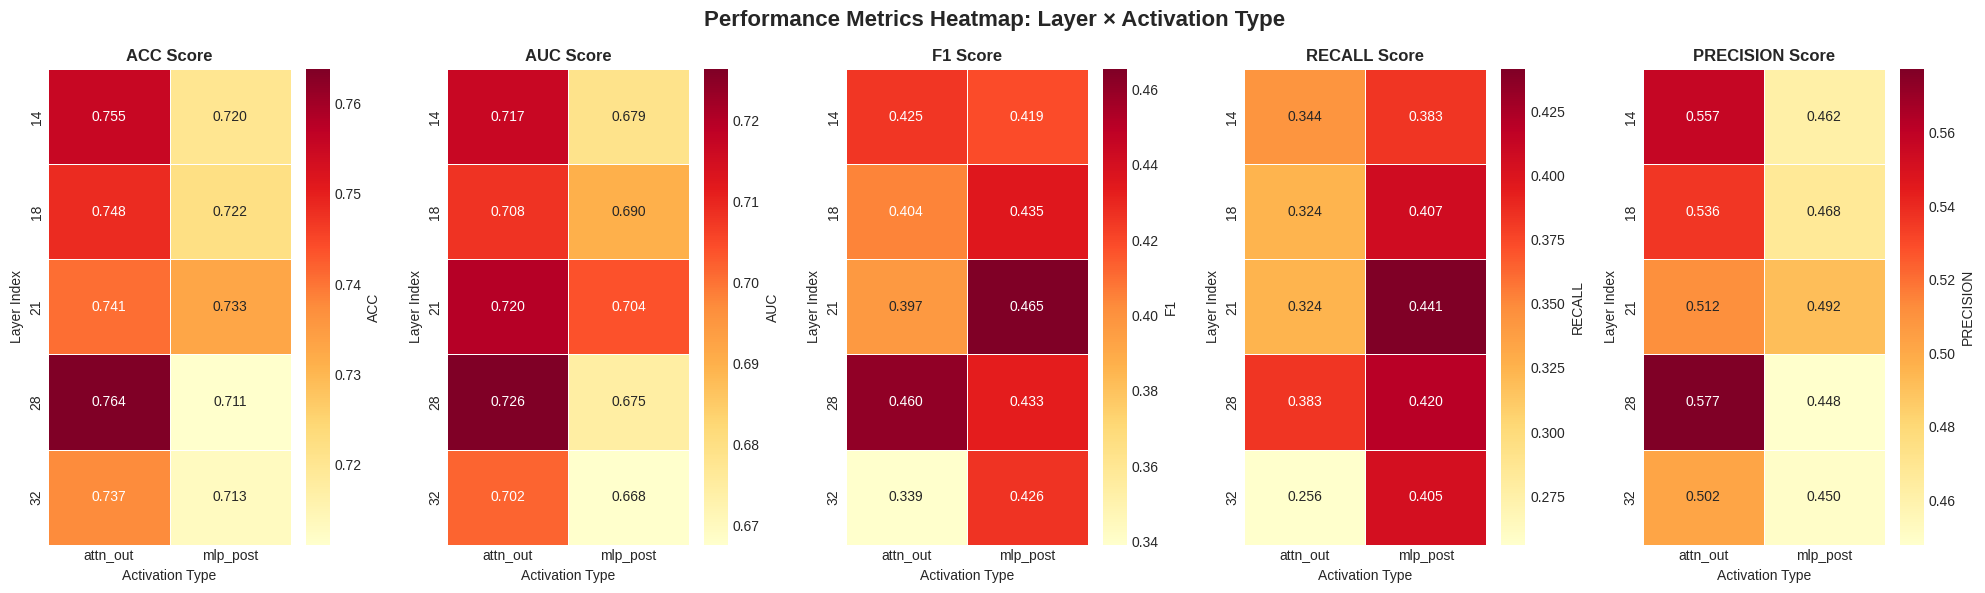

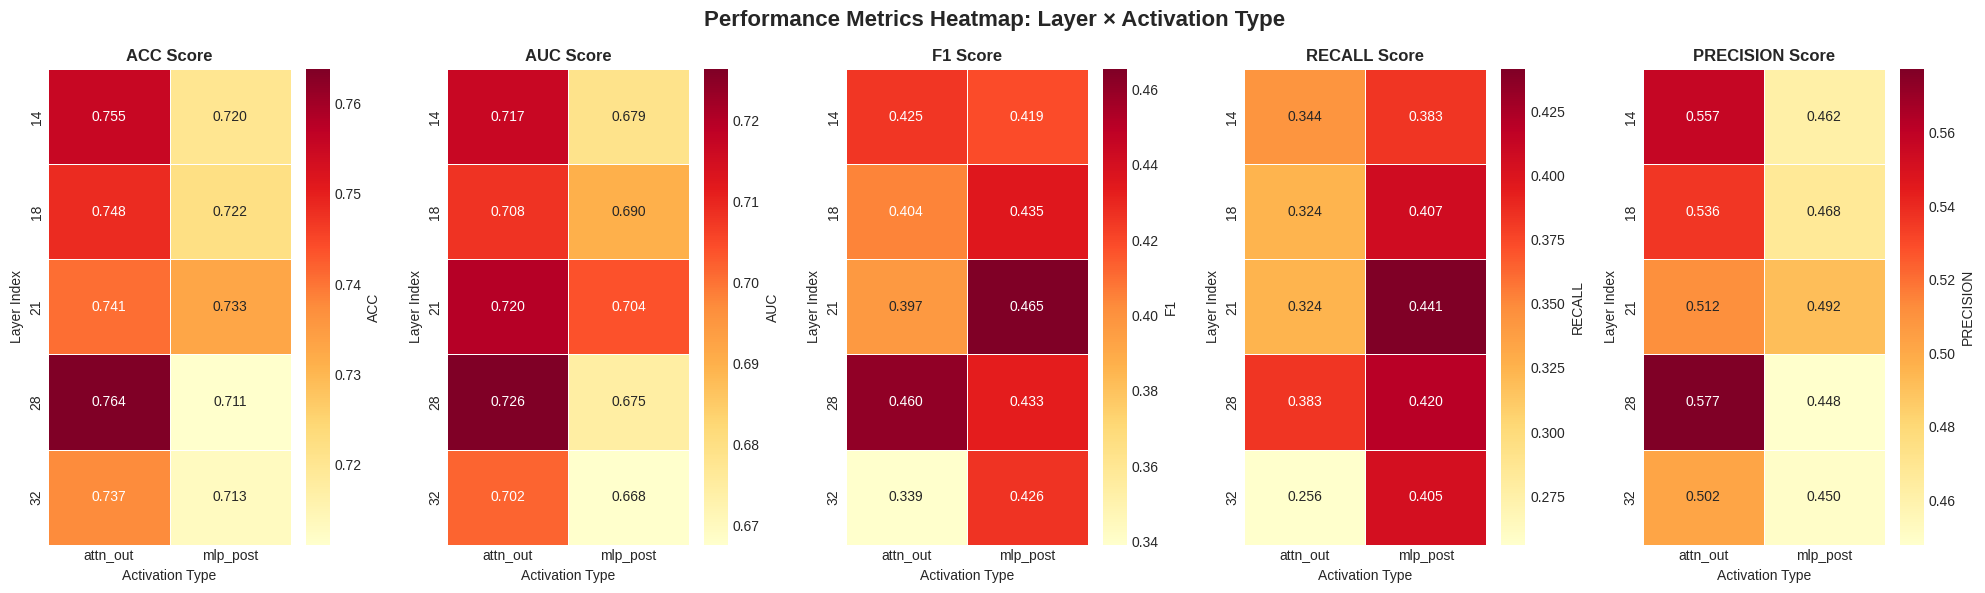

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_probe_metrics(df, save_path=None):
    """
    Plot metrics from linear probe experiments.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'layer_idx', 'act_type', 'acc', 'auc', 'f1', 'recall', 'precision'
    save_path : str, optional
        Path to save the figure. If None, displays the plot.
    """
    
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Linear Probe Performance Metrics by Layer and Activation Type', fontsize=16, fontweight='bold')
    
    # Metrics to plot
    metrics = ['acc', 'auc', 'f1', 'recall', 'precision']
    titles = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Recall', 'Precision']
    
    # Get unique activation types
    act_types = df['act_type'].unique()
    
    # Define colors for different activation types
    colors = plt.cm.Set2(np.linspace(0, 1, len(act_types)))
    
    # Plot each metric
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 3, idx % 3]
        
        for act_type, color in zip(act_types, colors):
            subset = df[df['act_type'] == act_type].sort_values('layer_idx')
            ax.plot(subset['layer_idx'], subset[metric], 
                   marker='o', linewidth=2, markersize=6, 
                   label=act_type, color=color)
            ax.fill_between(subset['layer_idx'], subset[metric], alpha=0.1, color=color)
        
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel(metric.upper(), fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        # Set y-axis limits with padding
        y_min = df[metric].min() - 0.05
        y_max = df[metric].max() + 0.05
        ax.set_ylim([max(0, y_min), min(1, y_max)])
    
    # Bottom subplot for training loss (if available)
    ax = axes[1, 2]
    if 'final_tr_loss' in df.columns and df['final_tr_loss'].notna().any():
        for act_type, color in zip(act_types, colors):
            subset = df[df['act_type'] == act_type].sort_values('layer_idx')
            if subset['final_tr_loss'].notna().any():
                ax.plot(subset['layer_idx'], subset['final_tr_loss'], 
                       marker='s', linewidth=2, markersize=6, 
                       label=act_type, color=color)
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel('Training Loss', fontsize=12)
        ax.set_title('Final Training Loss', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    else:
        # Create a bar plot comparing act_types across metrics
        ax.axis('off')
        ax.text(0.5, 0.5, 'No training loss data available', 
               ha='center', va='center', transform=ax.transAxes,
               fontsize=12, style='italic', alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    else:
        plt.show()
    
    return fig


def plot_metric_heatmap(df, save_path=None):
    """
    Create a heatmap of metrics across layers and activation types.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'layer_idx', 'act_type', and metrics
    save_path : str, optional
        Path to save the figure.
    """
    
    # Pivot data for heatmap
    metrics = ['acc', 'auc', 'f1', 'recall', 'precision']
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
    fig.suptitle('Performance Metrics Heatmap: Layer × Activation Type', fontsize=16, fontweight='bold')
    
    for idx, metric in enumerate(metrics):
        pivot_df = df.pivot(index='layer_idx', columns='act_type', values=metric)
        
        # Create heatmap
        sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='YlOrRd', 
                   ax=axes[idx], cbar_kws={'label': metric.upper()},
                   linewidths=0.5, linecolor='white')
        axes[idx].set_title(f'{metric.upper()} Score', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Activation Type', fontsize=10)
        axes[idx].set_ylabel('Layer Index', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to {save_path}")
    else:
        plt.show()
    
    return fig


# Example usage:
# Assuming your dataframe is named 'results'
plot_probe_metrics(results)
plot_metric_heatmap(results)
